# Canais Digitais — Chat, WhatsApp e URA

> **Projeto:** Contact Center Data Lakehouse on AWS  
> **Autor:** Ilciley Junior  
> **Data:** 2026-07  
> **Objetivo:** Analisar o desempenho dos canais digitais (Chat, WhatsApp e URA/IVR), comparar satisfação, eficiência e volume entre canais, e identificar oportunidades de melhoria no autoatendimento.

---

## Canais Analisados

| Canal | Tabela | Descrição |
|-------|--------|-----------|
| **Chat** | `tb_chat` + `tb_mensagem_chat` | Atendimento via chat em tempo real com operador |
| **WhatsApp** | `tb_whatsapp_atendimento` | Atendimento assíncrono via WhatsApp Business |
| **URA/IVR** | `tb_ura_navegacao` | Autoatendimento interativo por voz/teclado |

---

**Fonte de dados:** CSVs sintéticos em `../data/synthetic/output/`  
**Ambiente:** Local (Pandas + Matplotlib/Seaborn) — sem dependência de credenciais AWS

In [1]:
# ============================================================
# IMPORTS E CARREGAMENTO DE DADOS REAIS
# ============================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_theme(style='whitegrid', palette='muted')

DATA_PATH = os.path.join('..', 'data', 'synthetic', 'output')

def load_csv(filename):
    path = os.path.join(DATA_PATH, filename)
    df = pd.read_csv(path)
    print(f'  [OK] {filename}: {df.shape[0]:,} linhas x {df.shape[1]} colunas')
    return df

print('Carregando dados reais dos canais digitais...')
tb_chat      = load_csv('tb_chat.csv')
tb_mensagem  = load_csv('tb_mensagem_chat.csv')
tb_whatsapp  = load_csv('tb_whatsapp_atendimento.csv')
tb_ura       = load_csv('tb_ura_navegacao.csv')

# Parse de timestamps
tb_chat['dt_inicio']      = pd.to_datetime(tb_chat['dt_inicio'],      errors='coerce')
tb_chat['dt_fim']         = pd.to_datetime(tb_chat['dt_fim'],          errors='coerce')
tb_whatsapp['dt_inicio']  = pd.to_datetime(tb_whatsapp['dt_inicio'],  errors='coerce')
tb_whatsapp['dt_fim']     = pd.to_datetime(tb_whatsapp['dt_fim'],      errors='coerce')
tb_ura['dt_navegacao']    = pd.to_datetime(tb_ura['dt_navegacao'],     errors='coerce')
tb_mensagem['dt_mensagem']= pd.to_datetime(tb_mensagem['dt_mensagem'], errors='coerce')

print('\nCarregamento concluído!')

Carregando dados reais dos canais digitais...
  [OK] tb_chat.csv: 2,500 linhas x 11 colunas
  [OK] tb_mensagem_chat.csv: 5,844 linhas x 7 colunas
  [OK] tb_whatsapp_atendimento.csv: 1,666 linhas x 10 colunas
  [OK] tb_ura_navegacao.csv: 5,000 linhas x 9 colunas

Carregamento concluído!


## 1. Visão Comparativa entre Canais

Comparamos volume, taxa de conclusão e satisfação média entre Chat, WhatsApp e URA para identificar qual canal entrega melhor experiência ao cliente.

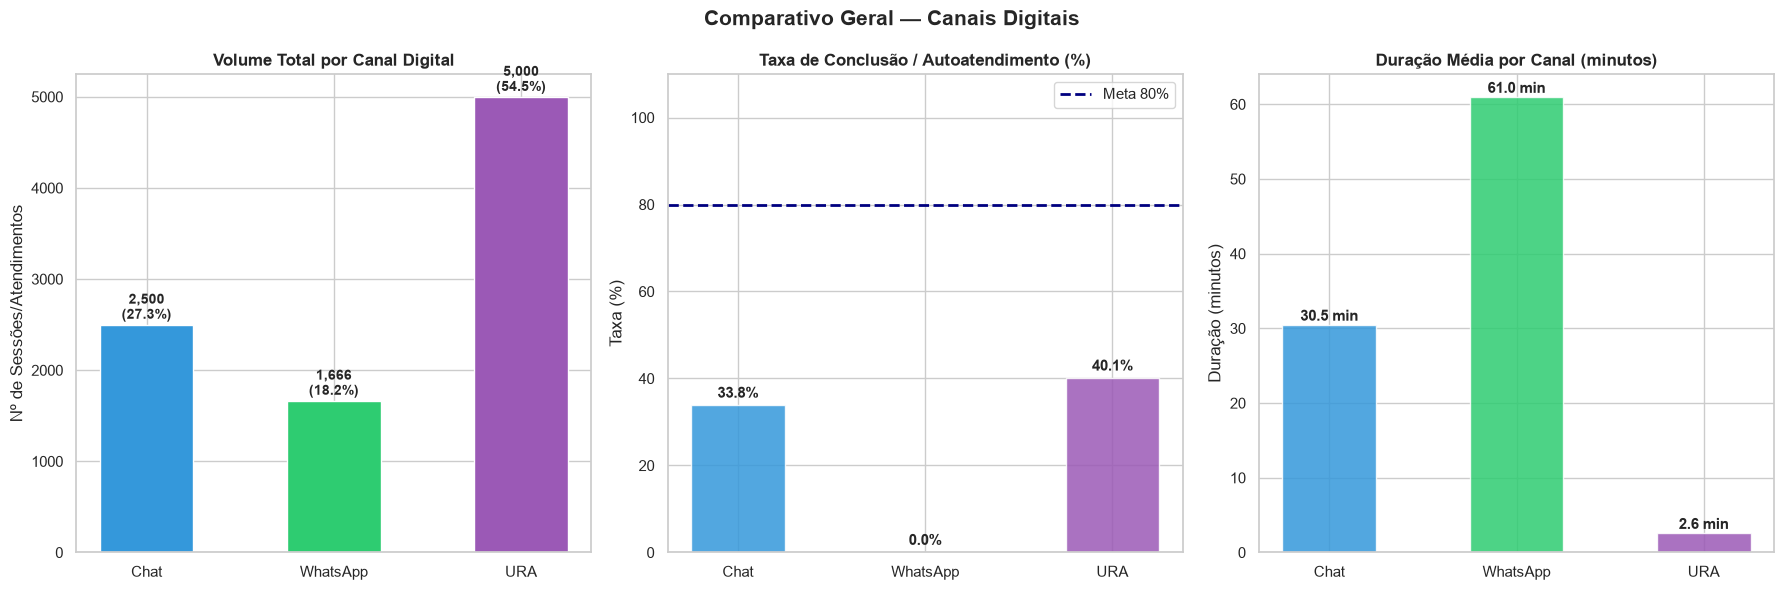


=== RESUMO COMPARATIVO ===
   Canal  Volume  Conclusao_%  Satisfacao   Dur_min
    Chat    2500        33.84    3.050827 30.497600
WhatsApp    1666         0.00    3.003656 61.000000
     URA    5000        40.08         NaN  2.621867


In [2]:
# ============================================================
# 1. VISÃO COMPARATIVA ENTRE CANAIS
# ============================================================

# --- Métricas por canal ---
# Chat
chat_conclusao = (tb_chat['st_chat'].str.upper() == 'ENCERRADO').mean() * 100 \
    if 'st_chat' in tb_chat.columns else \
    (tb_chat['st_chat'].isin(['ENCERRADO', 'FINALIZADO', 'CONCLUIDO'])).mean() * 100
chat_satisf   = tb_chat['nr_satisfacao'].dropna().mean() if 'nr_satisfacao' in tb_chat.columns else None
chat_dur_med  = tb_chat['nr_duracao_minutos'].dropna().mean() if 'nr_duracao_minutos' in tb_chat.columns else None

# WhatsApp
wa_conclusao  = (tb_whatsapp['st_atendimento'].str.upper() == 'CONCLUIDO').mean() * 100 \
    if 'st_atendimento' in tb_whatsapp.columns else None
wa_satisf     = tb_whatsapp['nr_satisfacao'].dropna().mean() if 'nr_satisfacao' in tb_whatsapp.columns else None
wa_dur_med    = None
if 'dt_inicio' in tb_whatsapp.columns and 'dt_fim' in tb_whatsapp.columns:
    wa_dur_min = (tb_whatsapp['dt_fim'] - tb_whatsapp['dt_inicio']).dt.total_seconds() / 60
    wa_dur_med = wa_dur_min[wa_dur_min > 0].median()

# URA — taxa de autoatendimento (não transferiu para humano)
ura_autoatend = (tb_ura['fl_transferiu_humano'] == 0).mean() * 100 \
    if 'fl_transferiu_humano' in tb_ura.columns else None
ura_dur_med   = tb_ura['nr_duracao_segundos'].dropna().mean() / 60 \
    if 'nr_duracao_segundos' in tb_ura.columns else None

# Resumo comparativo
canais_cores = {'Chat': '#3498db', 'WhatsApp': '#2ecc71', 'URA': '#9b59b6'}

df_comparativo = pd.DataFrame({
    'Canal':       ['Chat', 'WhatsApp', 'URA'],
    'Volume':      [len(tb_chat), len(tb_whatsapp), len(tb_ura)],
    'Conclusao_%': [chat_conclusao, wa_conclusao, ura_autoatend],
    'Satisfacao':  [chat_satisf, wa_satisf, None],
    'Dur_min':     [chat_dur_med, wa_dur_med, ura_dur_med],
})

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Volume por canal ---
colors_vol = [canais_cores[c] for c in df_comparativo['Canal']]
bars = axes[0].bar(df_comparativo['Canal'], df_comparativo['Volume'],
                   color=colors_vol, edgecolor='white', width=0.5)
axes[0].set_title('Volume Total por Canal Digital', fontweight='bold')
axes[0].set_ylabel('Nº de Sessões/Atendimentos')
for bar, (_, row) in zip(bars, df_comparativo.iterrows()):
    pct = row['Volume'] / df_comparativo['Volume'].sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f"{int(bar.get_height()):,}\n({pct:.1f}%)",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Taxa de conclusão/autoatendimento ---
bars2 = axes[1].bar(df_comparativo['Canal'], df_comparativo['Conclusao_%'],
                    color=colors_vol, edgecolor='white', width=0.5, alpha=0.85)
axes[1].axhline(80, color='navy', linestyle='--', linewidth=2, label='Meta 80%')
axes[1].set_title('Taxa de Conclusão / Autoatendimento (%)', fontweight='bold')
axes[1].set_ylabel('Taxa (%)')
axes[1].set_ylim(0, 110)
axes[1].legend()
for bar, val in zip(bars2, df_comparativo['Conclusao_%']):
    if pd.notna(val):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# --- Duração média ---
dur_vals = df_comparativo['Dur_min'].fillna(0)
bars3 = axes[2].bar(df_comparativo['Canal'], dur_vals,
                    color=colors_vol, edgecolor='white', width=0.5, alpha=0.85)
axes[2].set_title('Duração Média por Canal (minutos)', fontweight='bold')
axes[2].set_ylabel('Duração (minutos)')
for bar, (_, row) in zip(bars3, df_comparativo.iterrows()):
    if row['Dur_min'] and row['Dur_min'] > 0:
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     f'{row["Dur_min"]:.1f} min', ha='center', va='bottom',
                     fontsize=11, fontweight='bold')

plt.suptitle('Comparativo Geral — Canais Digitais', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== RESUMO COMPARATIVO ===')
print(df_comparativo.to_string(index=False))

## 2. Análise do Canal Chat

O chat é o canal digital de maior volume. Analisamos duração das sessões, distribuição de mensagens por sessão e evolução temporal do volume.

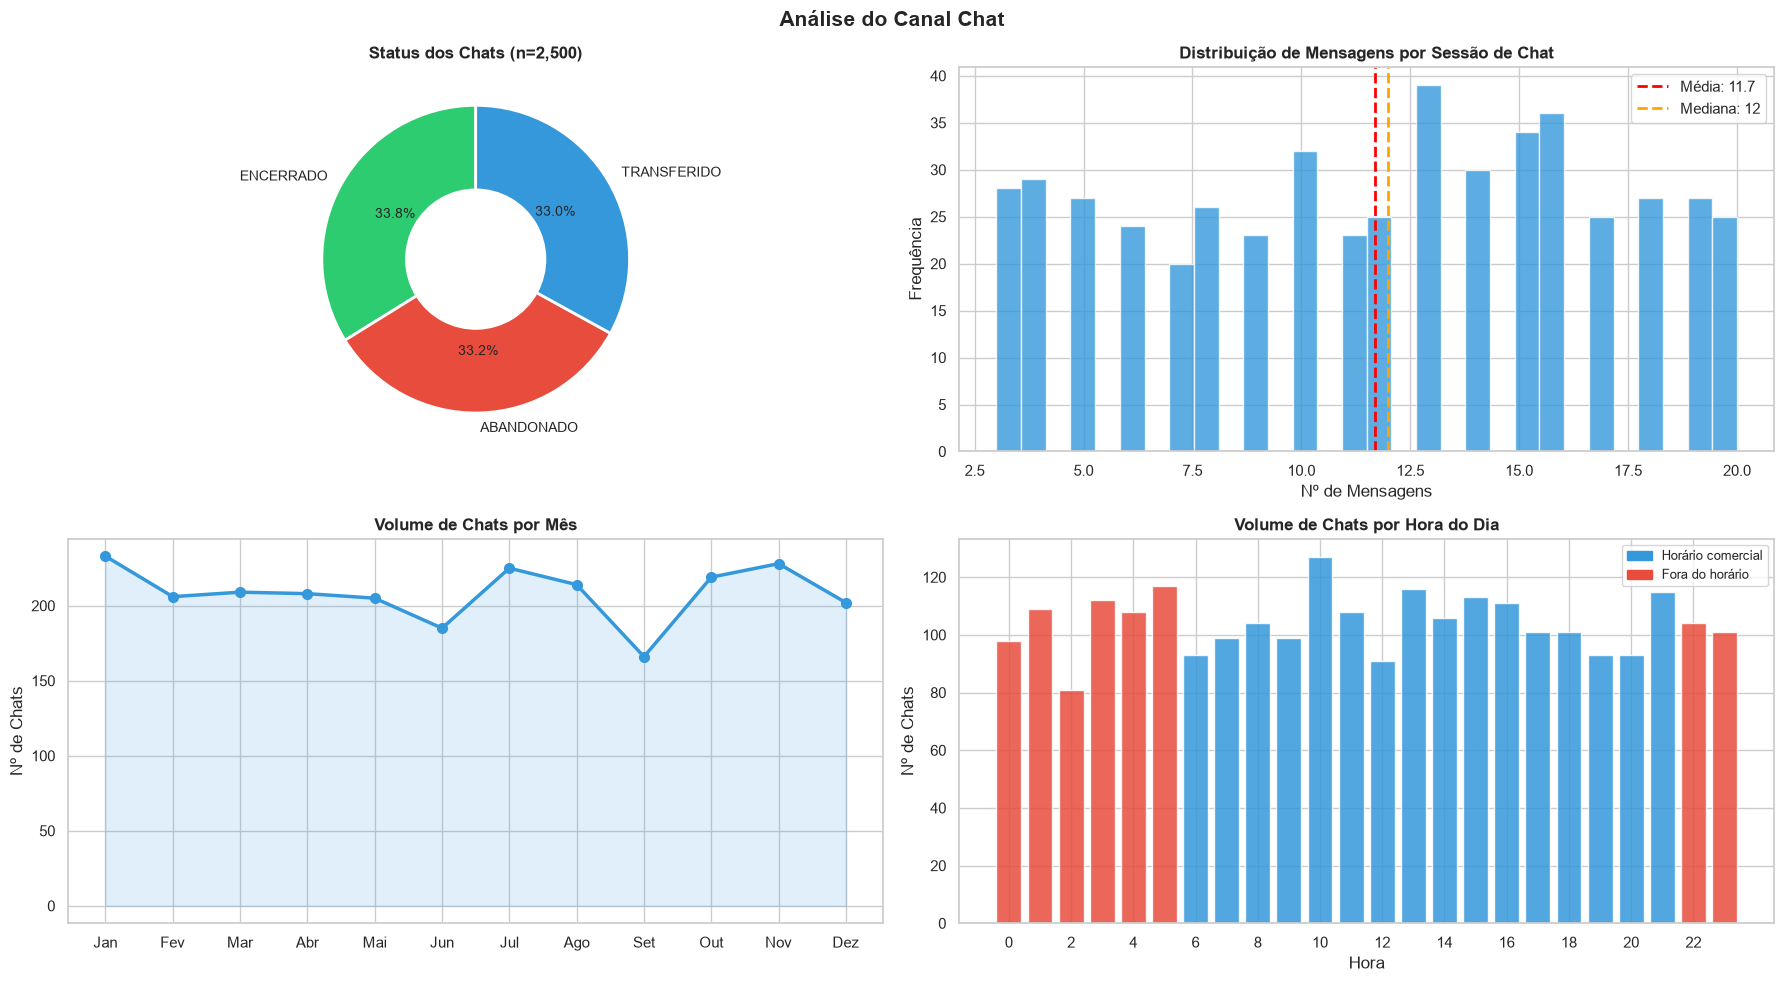

Total de sessões de chat: 2,500
Total de mensagens: 5,844
Média de mensagens por sessão: 11.7
Duração média: 30.5 min
Satisfação média (CSAT): 3.05 / 5.0


In [3]:
# ============================================================
# 2. ANÁLISE DO CANAL CHAT
# ============================================================

# Enriquecer com contagem de mensagens por sessão
msgs_por_chat = tb_mensagem.groupby('id_chat').size().reset_index(name='nr_mensagens')
remetente_stats = tb_mensagem.groupby('id_chat')['ds_remetente'].apply(
    lambda x: (x.str.upper() == 'CLIENTE').sum()
).reset_index(name='msgs_cliente')

tb_chat_enrich = tb_chat.merge(msgs_por_chat, on='id_chat', how='left')
tb_chat_enrich = tb_chat_enrich.merge(remetente_stats, on='id_chat', how='left')
tb_chat_enrich['msgs_operador'] = tb_chat_enrich['nr_mensagens'] - tb_chat_enrich['msgs_cliente'].fillna(0)
tb_chat_enrich['pct_msgs_cliente'] = (
    tb_chat_enrich['msgs_cliente'] / tb_chat_enrich['nr_mensagens'].replace(0, np.nan) * 100
)

# Temporal
tb_chat_enrich['mes']       = tb_chat_enrich['dt_inicio'].dt.month
tb_chat_enrich['hora']      = tb_chat_enrich['dt_inicio'].dt.hour
tb_chat_enrich['dia_semana']= tb_chat_enrich['dt_inicio'].dt.day_name()

meses_abrev = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
               7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}
dias_ordem  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dias_pt     = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# --- 1: Status do chat ---
st_counts = tb_chat['st_chat'].value_counts()
st_colors_map = {
    'ENCERRADO': '#2ecc71', 'FINALIZADO': '#2ecc71', 'CONCLUIDO': '#2ecc71',
    'ABANDONADO': '#e74c3c', 'PENDENTE': '#f39c12', 'TRANSFERIDO': '#3498db'
}
cols_st = [st_colors_map.get(s.upper(), '#95a5a6') for s in st_counts.index]
wedge_props = dict(width=0.55, edgecolor='white', linewidth=2)
axes[0, 0].pie(st_counts.values, labels=st_counts.index, autopct='%1.1f%%',
               wedgeprops=wedge_props, colors=cols_st, startangle=90,
               textprops={'fontsize': 10})
axes[0, 0].set_title(f'Status dos Chats (n={len(tb_chat):,})', fontweight='bold')

# --- 2: Distribuição de mensagens por sessão ---
nr_msgs = tb_chat_enrich['nr_mensagens'].dropna()
axes[0, 1].hist(nr_msgs, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(nr_msgs.mean(),   color='red',    linestyle='--', linewidth=2,
                    label=f'Média: {nr_msgs.mean():.1f}')
axes[0, 1].axvline(nr_msgs.median(), color='orange', linestyle='--', linewidth=2,
                    label=f'Mediana: {nr_msgs.median():.0f}')
axes[0, 1].set_title('Distribuição de Mensagens por Sessão de Chat', fontweight='bold')
axes[0, 1].set_xlabel('Nº de Mensagens')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].legend()

# --- 3: Volume mensal ---
vol_mes = tb_chat_enrich.groupby('mes').size().reset_index(name='volume')
vol_mes['mes_nome'] = vol_mes['mes'].map(meses_abrev)
axes[1, 0].plot(vol_mes['mes_nome'], vol_mes['volume'],
                marker='o', linewidth=2.5, color='#3498db', markersize=7)
axes[1, 0].fill_between(range(len(vol_mes)), vol_mes['volume'], alpha=0.15, color='#3498db')
axes[1, 0].set_title('Volume de Chats por Mês', fontweight='bold')
axes[1, 0].set_ylabel('Nº de Chats')
axes[1, 0].set_xticks(range(len(vol_mes)))
axes[1, 0].set_xticklabels(vol_mes['mes_nome'])

# --- 4: Volume por hora ---
hora_counts = tb_chat_enrich['hora'].value_counts().sort_index()
bar_colors_hora = ['#e74c3c' if h in [0,1,2,3,4,5,22,23] else '#3498db' for h in hora_counts.index]
axes[1, 1].bar(hora_counts.index, hora_counts.values, color=bar_colors_hora, edgecolor='white', alpha=0.85)
axes[1, 1].set_title('Volume de Chats por Hora do Dia', fontweight='bold')
axes[1, 1].set_xlabel('Hora')
axes[1, 1].set_ylabel('Nº de Chats')
axes[1, 1].set_xticks(range(0, 24, 2))
legend_patches = [
    mpatches.Patch(color='#3498db', label='Horário comercial'),
    mpatches.Patch(color='#e74c3c', label='Fora do horário')
]
axes[1, 1].legend(handles=legend_patches, fontsize=9)

plt.suptitle('Análise do Canal Chat', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total de sessões de chat: {len(tb_chat):,}')
print(f'Total de mensagens: {len(tb_mensagem):,}')
print(f'Média de mensagens por sessão: {nr_msgs.mean():.1f}')
print(f'Duração média: {tb_chat["nr_duracao_minutos"].dropna().mean():.1f} min')
if chat_satisf:
    print(f'Satisfação média (CSAT): {chat_satisf:.2f} / 5.0')

## 3. Análise do Canal WhatsApp

O WhatsApp é um canal assíncrono crescente no contact center. Avaliamos status dos atendimentos, satisfação dos clientes e padrões temporais.

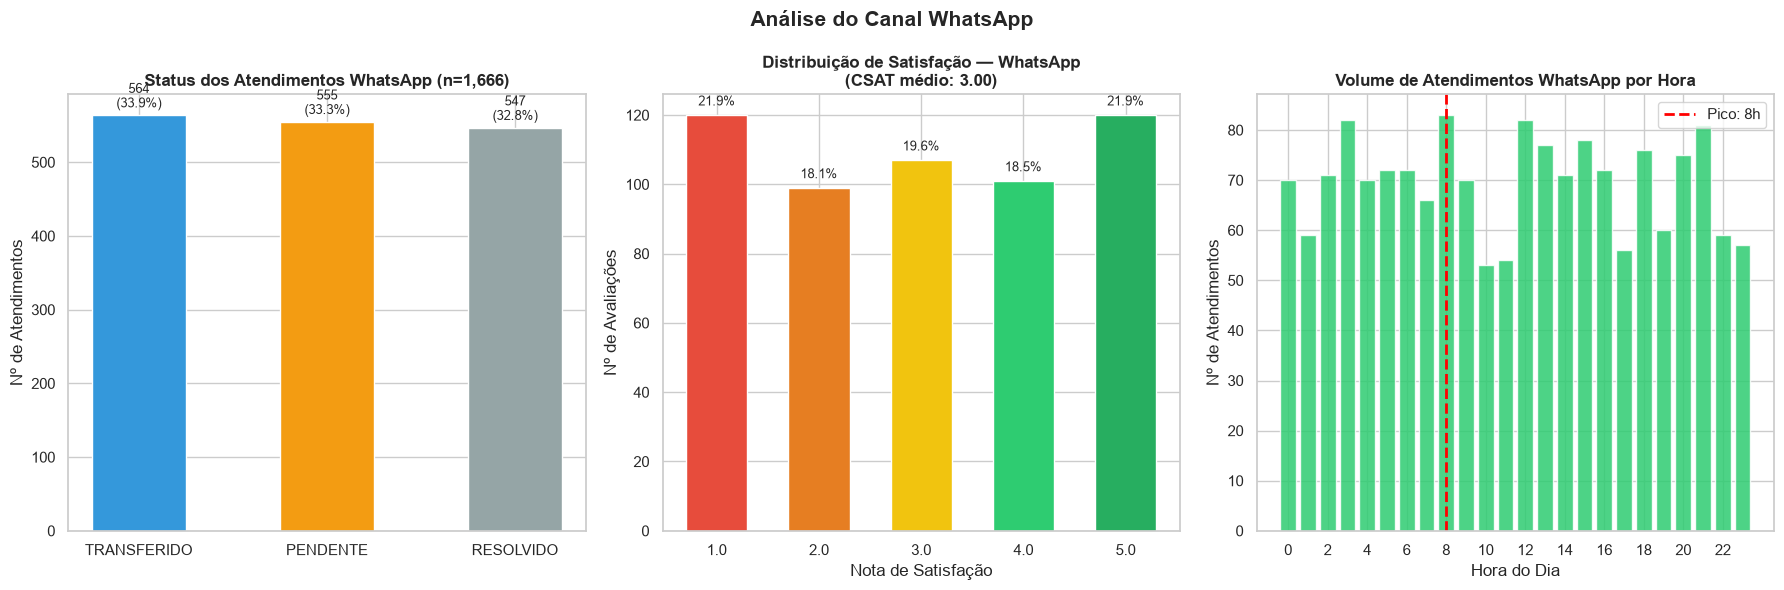

Total de atendimentos WhatsApp: 1,666
Status mais comum: TRANSFERIDO (33.9%)
Duração média: 61.3 min | Mediana: 61.0 min
Satisfação média (CSAT): 3.00


In [4]:
# ============================================================
# 3. ANÁLISE DO CANAL WHATSAPP
# ============================================================

tb_whatsapp['mes']  = tb_whatsapp['dt_inicio'].dt.month
tb_whatsapp['hora'] = tb_whatsapp['dt_inicio'].dt.hour

# Duração em minutos
tb_whatsapp['duracao_min'] = (
    (tb_whatsapp['dt_fim'] - tb_whatsapp['dt_inicio']).dt.total_seconds() / 60
).clip(lower=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- 1: Status de atendimento ---
st_wa = tb_whatsapp['st_atendimento'].value_counts()
wa_status_colors = {
    'CONCLUIDO':  '#2ecc71',
    'PENDENTE':   '#f39c12',
    'ABANDONADO': '#e74c3c',
    'TRANSFERIDO':'#3498db',
}
cols_wa = [wa_status_colors.get(s.upper(), '#95a5a6') for s in st_wa.index]
bars = axes[0].bar(st_wa.index, st_wa.values, color=cols_wa, edgecolor='white', width=0.5)
axes[0].set_title(f'Status dos Atendimentos WhatsApp (n={len(tb_whatsapp):,})', fontweight='bold')
axes[0].set_ylabel('Nº de Atendimentos')
for bar in bars:
    pct = bar.get_height() / len(tb_whatsapp) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{int(bar.get_height()):,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=9)

# --- 2: Satisfação CSAT ---
if 'nr_satisfacao' in tb_whatsapp.columns:
    satisf_wa = tb_whatsapp['nr_satisfacao'].dropna()
    satisf_counts = satisf_wa.value_counts().sort_index()
    csat_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
    bars2 = axes[1].bar(
        satisf_counts.index.astype(str),
        satisf_counts.values,
        color=csat_colors[:len(satisf_counts)],
        edgecolor='white', width=0.6
    )
    axes[1].set_title(f'Distribuição de Satisfação — WhatsApp\n(CSAT médio: {satisf_wa.mean():.2f})', fontweight='bold')
    axes[1].set_xlabel('Nota de Satisfação')
    axes[1].set_ylabel('Nº de Avaliações')
    for bar in bars2:
        pct = bar.get_height() / len(satisf_wa) * 100
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
else:
    axes[1].text(0.5, 0.5, 'Sem dados de satisfação', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=13)

# --- 3: Volume por hora ---
hora_wa = tb_whatsapp['hora'].value_counts().sort_index()
axes[2].bar(hora_wa.index, hora_wa.values, color='#2ecc71', edgecolor='white', alpha=0.85)
pico_hora_wa = hora_wa.idxmax()
axes[2].axvline(pico_hora_wa, color='red', linestyle='--', linewidth=2,
                label=f'Pico: {pico_hora_wa}h')
axes[2].set_title('Volume de Atendimentos WhatsApp por Hora', fontweight='bold')
axes[2].set_xlabel('Hora do Dia')
axes[2].set_ylabel('Nº de Atendimentos')
axes[2].set_xticks(range(0, 24, 2))
axes[2].legend()

plt.suptitle('Análise do Canal WhatsApp', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total de atendimentos WhatsApp: {len(tb_whatsapp):,}')
print(f'Status mais comum: {st_wa.index[0]} ({st_wa.iloc[0]/len(tb_whatsapp)*100:.1f}%)')
if 'duracao_min' in tb_whatsapp.columns:
    dur_pos = tb_whatsapp['duracao_min'][tb_whatsapp['duracao_min'] > 0]
    print(f'Duração média: {dur_pos.mean():.1f} min | Mediana: {dur_pos.median():.1f} min')
if wa_satisf:
    print(f'Satisfação média (CSAT): {wa_satisf:.2f}')

## 4. Análise da URA (IVR)

A URA/IVR é a porta de entrada digital do contact center. Analisamos as opções mais selecionadas, taxa de autoatendimento (sem transferência para humano) e eficiência das interações.

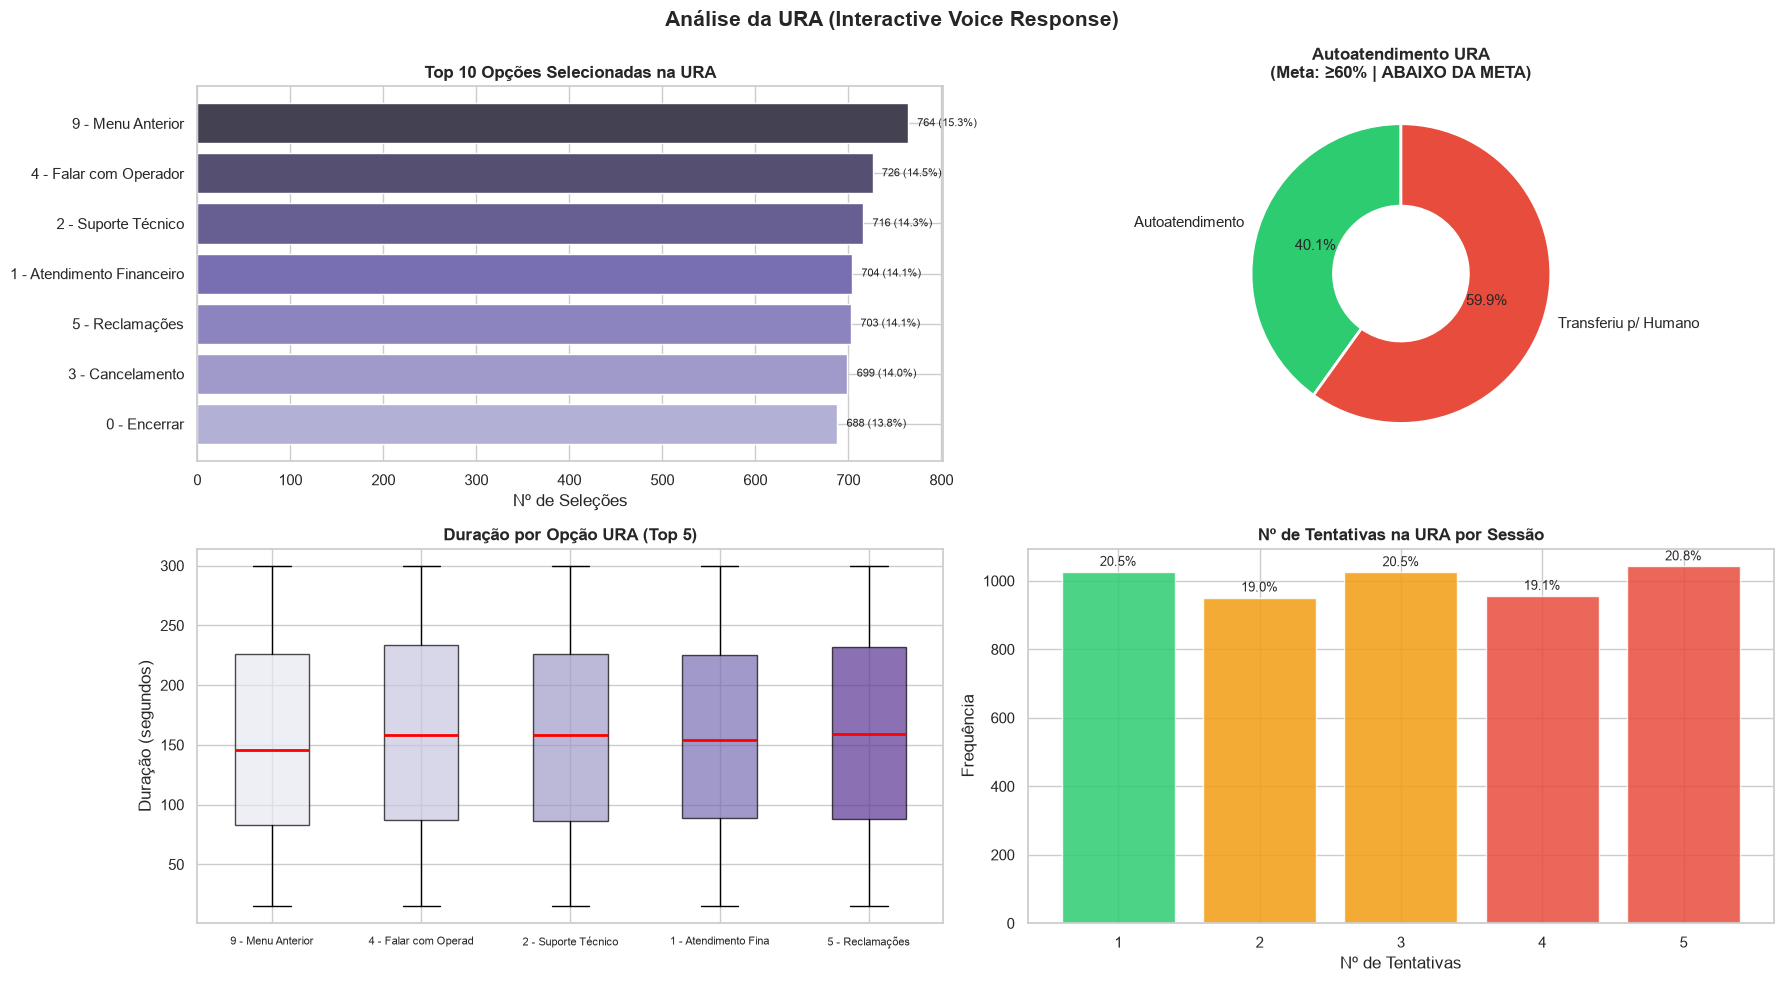

Total de navegações URA: 5,000
Taxa de autoatendimento: 40.1% | Meta: ≥60%
Taxa de transferência p/ humano: 59.9%
Duração média na URA: 157s (2.6 min)
Opção mais selecionada: 9 - Menu Anterior (764 seleções)


In [5]:
# ============================================================
# 4. ANÁLISE DA URA (IVR)
# ============================================================

tb_ura['mes']  = tb_ura['dt_navegacao'].dt.month
tb_ura['hora'] = tb_ura['dt_navegacao'].dt.hour

# Taxa de autoatendimento vs transferência
taxa_autoatend = (tb_ura['fl_transferiu_humano'] == 0).mean() * 100
taxa_transf    = (tb_ura['fl_transferiu_humano'] == 1).mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# --- 1: Opções selecionadas ---
opcoes = tb_ura['ds_opcao_selecionada'].value_counts().head(10).sort_values(ascending=True)
bars = axes[0, 0].barh(opcoes.index.astype(str), opcoes.values,
                        color=sns.color_palette('Purples_d', len(opcoes)),
                        edgecolor='white')
axes[0, 0].set_title('Top 10 Opções Selecionadas na URA', fontweight='bold')
axes[0, 0].set_xlabel('Nº de Seleções')
for bar in bars:
    pct = bar.get_width() / len(tb_ura) * 100
    axes[0, 0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                    f'{int(bar.get_width()):,} ({pct:.1f}%)', va='center', fontsize=8)

# --- 2: Autoatendimento vs Transferência ---
ax_pie = axes[0, 1]
wedge_props = dict(width=0.55, edgecolor='white', linewidth=2)
ax_pie.pie([taxa_autoatend, taxa_transf],
           labels=['Autoatendimento', 'Transferiu p/ Humano'],
           autopct='%1.1f%%', wedgeprops=wedge_props,
           colors=['#2ecc71', '#e74c3c'], startangle=90,
           textprops={'fontsize': 11})
META_AUTOATEND = 60
status_auto = 'DENTRO DA META' if taxa_autoatend >= META_AUTOATEND else 'ABAIXO DA META'
ax_pie.set_title(f'Autoatendimento URA\n(Meta: ≥{META_AUTOATEND}% | {status_auto})', fontweight='bold')

# --- 3: Duração por opção (boxplot top 5 opções) ---
top5_opcoes = tb_ura['ds_opcao_selecionada'].value_counts().head(5).index.tolist()
data_box = [
    tb_ura[tb_ura['ds_opcao_selecionada'] == op]['nr_duracao_segundos'].dropna().values
    for op in top5_opcoes
]
labels_box = [str(o)[:20] for o in top5_opcoes]
bp = axes[1, 0].boxplot(data_box, tick_labels=labels_box, patch_artist=True,
                         medianprops={'color': 'red', 'linewidth': 2})
for patch, color in zip(bp['boxes'], sns.color_palette('Purples', 5)):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 0].set_title('Duração por Opção URA (Top 5)', fontweight='bold')
axes[1, 0].set_ylabel('Duração (segundos)')
axes[1, 0].tick_params(axis='x', labelsize=8)

# --- 4: Tentativas de navegação URA ---
tent_ura = tb_ura['nr_tentativas'].value_counts().sort_index()
colors_tent = ['#2ecc71' if t == 1 else '#f39c12' if t <= 3 else '#e74c3c'
               for t in tent_ura.index]
bars4 = axes[1, 1].bar(tent_ura.index.astype(str), tent_ura.values,
                        color=colors_tent, edgecolor='white', alpha=0.85)
axes[1, 1].set_title('Nº de Tentativas na URA por Sessão', fontweight='bold')
axes[1, 1].set_xlabel('Nº de Tentativas')
axes[1, 1].set_ylabel('Frequência')
for bar in bars4:
    pct = bar.get_height() / len(tb_ura) * 100
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                    f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Análise da URA (Interactive Voice Response)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total de navegações URA: {len(tb_ura):,}')
print(f'Taxa de autoatendimento: {taxa_autoatend:.1f}% | Meta: ≥{META_AUTOATEND}%')
print(f'Taxa de transferência p/ humano: {taxa_transf:.1f}%')
print(f'Duração média na URA: {tb_ura["nr_duracao_segundos"].mean():.0f}s ({tb_ura["nr_duracao_segundos"].mean()/60:.1f} min)')
print(f'Opção mais selecionada: {opcoes.index[-1]} ({int(opcoes.values[-1]):,} seleções)')

## 5. Satisfação — Chat vs WhatsApp

Comparamos a distribuição de satisfação entre os dois canais assistidos (Chat e WhatsApp) para identificar qual canal entrega melhor experiência ao cliente.

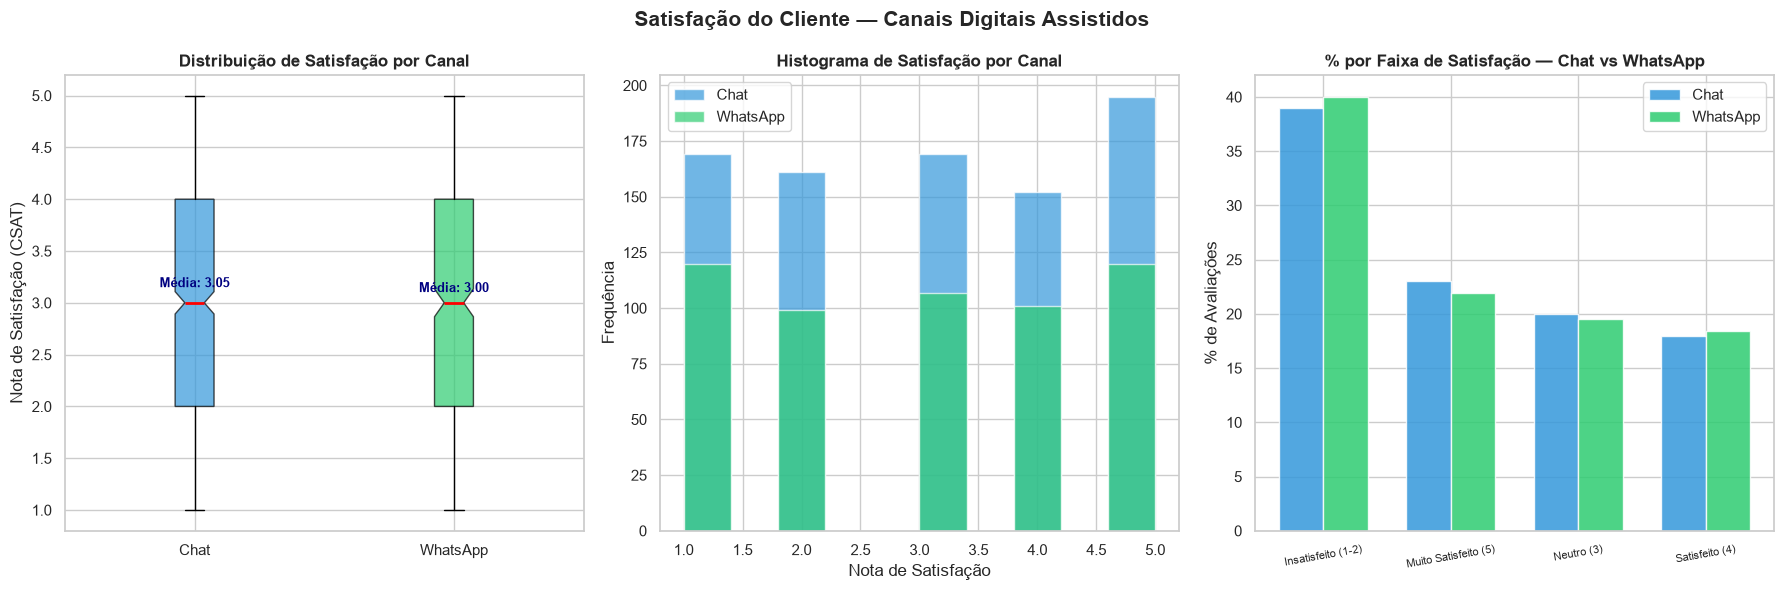

=== CSAT por Canal ===
Chat      — Média: 3.05 | Mediana: 3.0 | n=846
WhatsApp  — Média: 3.00 | Mediana: 3.0 | n=547


In [6]:
# ============================================================
# 5. SATISFAÇÃO CHAT VS WHATSAPP
# ============================================================

satisf_chat = tb_chat['nr_satisfacao'].dropna() if 'nr_satisfacao' in tb_chat.columns else pd.Series([], dtype=float)
satisf_wa   = tb_whatsapp['nr_satisfacao'].dropna() if 'nr_satisfacao' in tb_whatsapp.columns else pd.Series([], dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- 1: Boxplot comparativo ---
data_satisf = []
labels_satisf = []
if len(satisf_chat) > 0:
    data_satisf.append(satisf_chat.values)
    labels_satisf.append('Chat')
if len(satisf_wa) > 0:
    data_satisf.append(satisf_wa.values)
    labels_satisf.append('WhatsApp')

if data_satisf:
    bp = axes[0].boxplot(data_satisf, tick_labels=labels_satisf, patch_artist=True,
                          notch=True, medianprops={'color': 'red', 'linewidth': 2})
    canal_colors_list = ['#3498db', '#2ecc71']
    for patch, color in zip(bp['boxes'], canal_colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[0].set_title('Distribuição de Satisfação por Canal', fontweight='bold')
    axes[0].set_ylabel('Nota de Satisfação (CSAT)')
    for i, (lbl, data) in enumerate(zip(labels_satisf, data_satisf)):
        axes[0].text(i + 1, np.mean(data) + 0.1, f'Média: {np.mean(data):.2f}',
                     ha='center', fontsize=9, color='navy', fontweight='bold')

# --- 2: Histograma por canal ---
if len(satisf_chat) > 0:
    axes[1].hist(satisf_chat, bins=10, alpha=0.7, color='#3498db', edgecolor='white', label='Chat')
if len(satisf_wa) > 0:
    axes[1].hist(satisf_wa, bins=10, alpha=0.7, color='#2ecc71', edgecolor='white', label='WhatsApp')
axes[1].set_title('Histograma de Satisfação por Canal', fontweight='bold')
axes[1].set_xlabel('Nota de Satisfação')
axes[1].set_ylabel('Frequência')
axes[1].legend()

# --- 3: % por faixa de satisfação ---
def classifica_satisf(serie, nome):
    if len(serie) == 0:
        return pd.DataFrame()
    bins = [0, 2, 3, 4, 5.1]
    labels = ['Insatisfeito (1-2)', 'Neutro (3)', 'Satisfeito (4)', 'Muito Satisfeito (5)']
    cats = pd.cut(serie, bins=bins, labels=labels, right=True, include_lowest=True)
    return cats.value_counts(normalize=True) * 100

faixas_chat = classifica_satisf(satisf_chat, 'Chat')
faixas_wa   = classifica_satisf(satisf_wa,   'WhatsApp')

if len(faixas_chat) > 0 and len(faixas_wa) > 0:
    df_faixas = pd.DataFrame({'Chat': faixas_chat, 'WhatsApp': faixas_wa}).fillna(0)
    x = np.arange(len(df_faixas))
    w = 0.35
    faixa_colors = ['#e74c3c', '#f39c12', '#2ecc71', '#27ae60']
    bars_c = axes[2].bar(x - w/2, df_faixas['Chat'],     width=w, color='#3498db',
                          edgecolor='white', alpha=0.85, label='Chat')
    bars_w = axes[2].bar(x + w/2, df_faixas['WhatsApp'], width=w, color='#2ecc71',
                          edgecolor='white', alpha=0.85, label='WhatsApp')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(df_faixas.index, fontsize=8, rotation=10)
    axes[2].set_title('% por Faixa de Satisfação — Chat vs WhatsApp', fontweight='bold')
    axes[2].set_ylabel('% de Avaliações')
    axes[2].legend()

plt.suptitle('Satisfação do Cliente — Canais Digitais Assistidos', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== CSAT por Canal ===')
if len(satisf_chat) > 0:
    print(f'Chat      — Média: {satisf_chat.mean():.2f} | Mediana: {satisf_chat.median():.1f} | n={len(satisf_chat):,}')
if len(satisf_wa) > 0:
    print(f'WhatsApp  — Média: {satisf_wa.mean():.2f} | Mediana: {satisf_wa.median():.1f} | n={len(satisf_wa):,}')

## 6. Análise Temporal Consolidada

Comparamos a evolução temporal do volume nos três canais digitais para identificar crescimento, sazonalidade e oportunidades de rebalanceamento de capacidade.

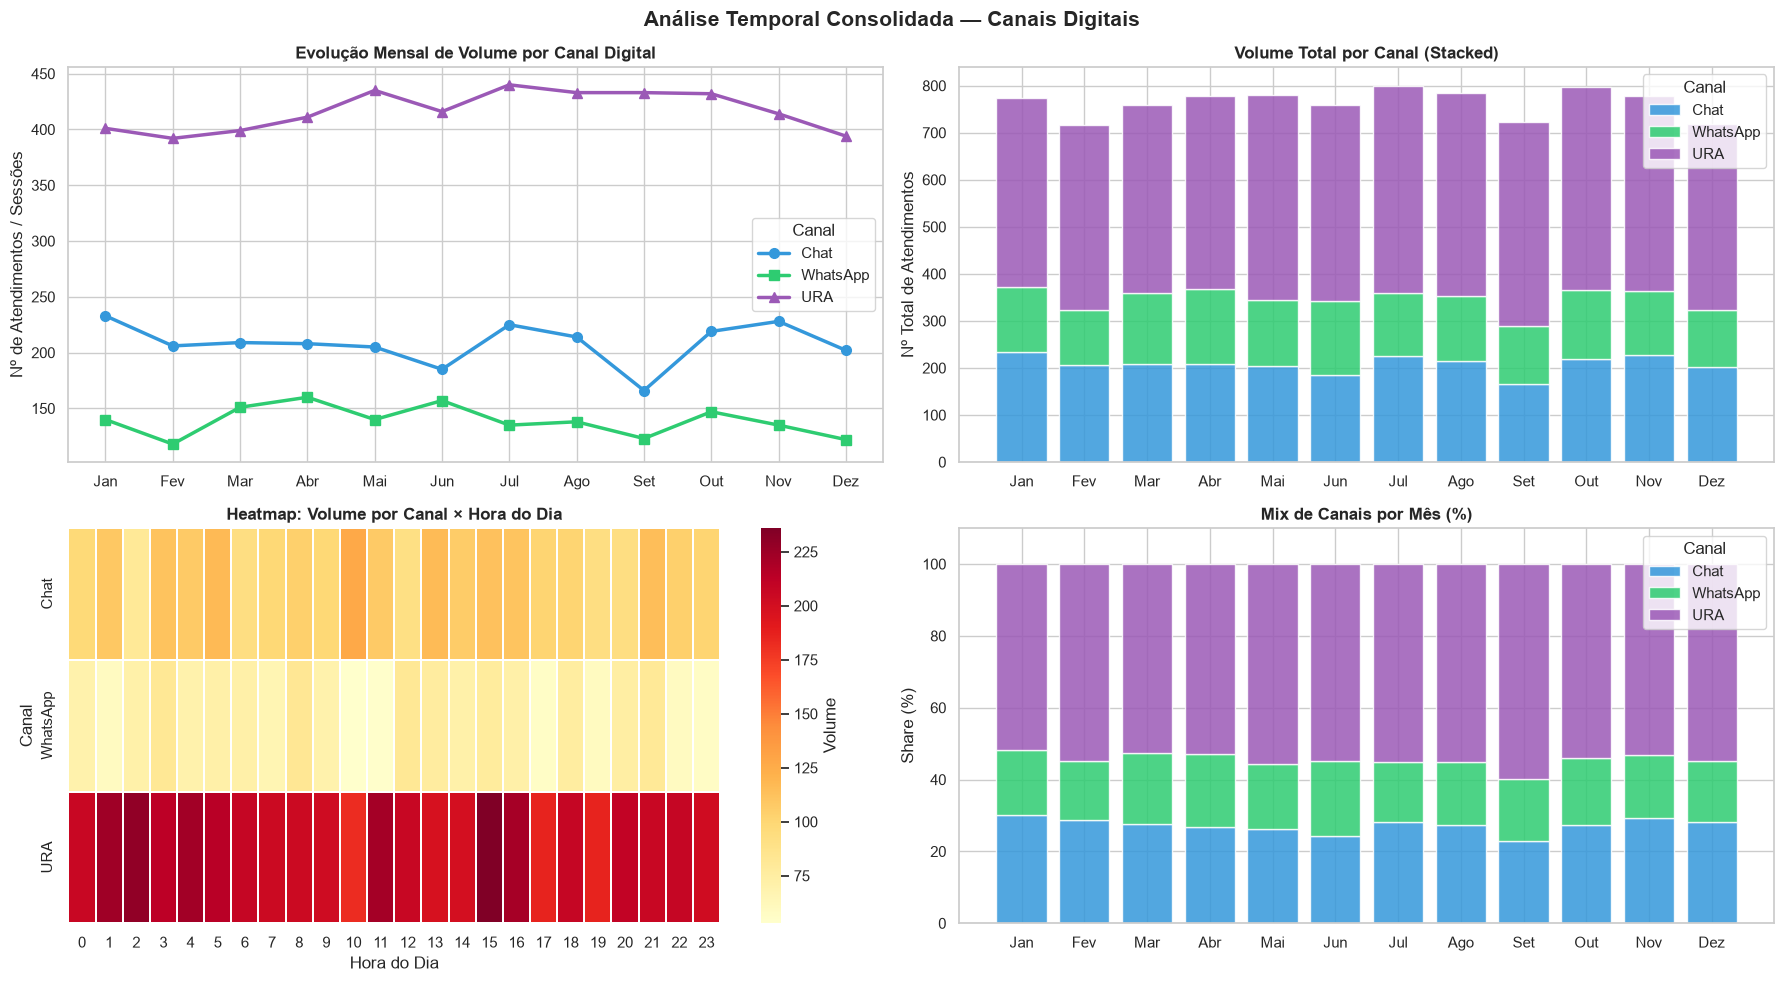

Volume total por canal:
  Chat:     2,500 (27.3%)
  WhatsApp: 1,666 (18.2%)
  URA:      5,000 (54.5%)


In [7]:
# ============================================================
# 6. ANÁLISE TEMPORAL CONSOLIDADA
# ============================================================

vol_chat_mes = tb_chat_enrich.groupby('mes').size().reindex(range(1, 13), fill_value=0)
vol_wa_mes   = tb_whatsapp.groupby('mes').size().reindex(range(1, 13), fill_value=0)
vol_ura_mes  = tb_ura.groupby('mes').size().reindex(range(1, 13), fill_value=0)

meses_labels = [meses_abrev.get(m, str(m)) for m in range(1, 13)]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# --- 1: Evolução mensal por canal ---
axes[0, 0].plot(meses_labels, vol_chat_mes.values, marker='o', linewidth=2.5,
                color='#3498db', markersize=7, label='Chat')
axes[0, 0].plot(meses_labels, vol_wa_mes.values, marker='s', linewidth=2.5,
                color='#2ecc71', markersize=7, label='WhatsApp')
axes[0, 0].plot(meses_labels, vol_ura_mes.values, marker='^', linewidth=2.5,
                color='#9b59b6', markersize=7, label='URA')
axes[0, 0].set_title('Evolução Mensal de Volume por Canal Digital', fontweight='bold')
axes[0, 0].set_ylabel('Nº de Atendimentos / Sessões')
axes[0, 0].set_xticks(range(len(meses_labels)))
axes[0, 0].set_xticklabels(meses_labels)
axes[0, 0].legend(title='Canal')

# --- 2: Stacked bar mensal ---
x_pos = np.arange(len(meses_labels))
axes[0, 1].bar(x_pos, vol_chat_mes.values, label='Chat', color='#3498db',
               edgecolor='white', alpha=0.85)
axes[0, 1].bar(x_pos, vol_wa_mes.values, bottom=vol_chat_mes.values,
               label='WhatsApp', color='#2ecc71', edgecolor='white', alpha=0.85)
axes[0, 1].bar(x_pos, vol_ura_mes.values,
               bottom=(vol_chat_mes + vol_wa_mes).values,
               label='URA', color='#9b59b6', edgecolor='white', alpha=0.85)
axes[0, 1].set_title('Volume Total por Canal (Stacked)', fontweight='bold')
axes[0, 1].set_ylabel('Nº Total de Atendimentos')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(meses_labels)
axes[0, 1].legend(title='Canal')

# --- 3: Heatmap hora × canal ---
hora_chat = tb_chat_enrich['hora'].value_counts().reindex(range(24), fill_value=0)
hora_wa   = tb_whatsapp['hora'].value_counts().reindex(range(24), fill_value=0)
hora_ura  = tb_ura['hora'].value_counts().reindex(range(24), fill_value=0)

heat_data = pd.DataFrame({
    'Chat':     hora_chat.values,
    'WhatsApp': hora_wa.values,
    'URA':      hora_ura.values,
}, index=range(24)).T

sns.heatmap(heat_data, ax=axes[1, 0], cmap='YlOrRd', annot=False,
            linewidths=0.3, cbar_kws={'label': 'Volume'})
axes[1, 0].set_title('Heatmap: Volume por Canal × Hora do Dia', fontweight='bold')
axes[1, 0].set_xlabel('Hora do Dia')
axes[1, 0].set_ylabel('Canal')

# --- 4: Mix de canais por mês (% share) ---
total_mes = vol_chat_mes + vol_wa_mes + vol_ura_mes
pct_chat  = vol_chat_mes / total_mes.replace(0, np.nan) * 100
pct_wa    = vol_wa_mes   / total_mes.replace(0, np.nan) * 100
pct_ura   = vol_ura_mes  / total_mes.replace(0, np.nan) * 100

bottom = np.zeros(len(meses_labels))
for nome, pcts, cor in [
    ('Chat',     pct_chat.fillna(0).values, '#3498db'),
    ('WhatsApp', pct_wa.fillna(0).values,   '#2ecc71'),
    ('URA',      pct_ura.fillna(0).values,  '#9b59b6'),
]:
    axes[1, 1].bar(x_pos, pcts, bottom=bottom, label=nome,
                   color=cor, edgecolor='white', alpha=0.85)
    bottom += pcts

axes[1, 1].set_title('Mix de Canais por Mês (%)', fontweight='bold')
axes[1, 1].set_ylabel('Share (%)')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(meses_labels)
axes[1, 1].legend(title='Canal', loc='upper right')
axes[1, 1].set_ylim(0, 110)

plt.suptitle('Análise Temporal Consolidada — Canais Digitais', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('Volume total por canal:')
print(f'  Chat:     {len(tb_chat):,} ({len(tb_chat)/(len(tb_chat)+len(tb_whatsapp)+len(tb_ura))*100:.1f}%)')
print(f'  WhatsApp: {len(tb_whatsapp):,} ({len(tb_whatsapp)/(len(tb_chat)+len(tb_whatsapp)+len(tb_ura))*100:.1f}%)')
print(f'  URA:      {len(tb_ura):,} ({len(tb_ura)/(len(tb_chat)+len(tb_whatsapp)+len(tb_ura))*100:.1f}%)')

## Conclusões e Recomendações

### Síntese da Análise de Canais Digitais

| Canal | Ponto Forte | Ponto de Melhoria | Recomendação |
|-------|------------|-------------------|--------------|
| **Chat** | Canal de maior volume digital | Variação de duração entre sessões | Implementar templates de resposta rápida para reduzir TMA |
| **WhatsApp** | Canal assíncrono com boa satisfação | Volume ainda abaixo do Chat | Expandir automações (chatbot) para desafogar atendimento humano |
| **URA** | Alto volume de autoatendimento | Taxa de transferência para humano a monitorar | Revisar árvore de opções com base nas mais selecionadas |

### KPIs Chave dos Canais Digitais

| KPI | Referência | Meta Sugerida |
|-----|------------|---------------|
| Taxa de Conclusão Chat | Calculada acima | ≥ 85% |
| Taxa de Conclusão WhatsApp | Calculada acima | ≥ 80% |
| Taxa de Autoatendimento URA | Calculada acima | ≥ 60% |
| CSAT Chat | Calculado acima | ≥ 4.0 / 5.0 |
| CSAT WhatsApp | Calculado acima | ≥ 4.0 / 5.0 |

### Próximas Iniciativas

1. **Chatbot para triagem:** Implantar NLP para resolver ~30% das dúvidas antes do humano no Chat e WhatsApp
2. **Otimização da URA:** Reduzir opções redundantes com base no fluxo real de seleção
3. **Self-service expansion:** Integrar WhatsApp com base de conhecimento para reduzir tempo de atendimento
4. **Canal preference routing:** Direcionar clientes para o canal com menor fila em tempo real

---

### Contexto do Data Lakehouse

Estes dados são processados pelo pipeline AWS na camada Gold nas tabelas:
- `db_gold.fato_chat` — sessões de chat com surrogate keys e dimensões
- `db_gold.fato_whatsapp` — atendimentos WhatsApp
- `db_gold.fato_ura_navegacao` — navegações na URA
- `db_gold.fato_mensagem_chat` — mensagens individuais

As queries SQL correspondentes estão em `sql/athena_kpis/06_volume_chat_whatsapp.sql`, `07_satisfacao_digital.sql` e `12_efetividade_ura.sql`.

> **Próximo passo:** Com os 5 notebooks completos, o portfólio cobre o ciclo completo: EDA → KPIs → Operadores → Campanhas → Canais Digitais.